# 03 - MaxCut with QAOA

This notebook builds a small MaxCut-QAOA pipeline with the padopauli `Circuit` API:
1. Define a graph and MaxCut objective
2. Build a QAOA circuit
3. Train QAOA angles by minimizing `sum Z_i Z_j` over edges
4. Compare against brute-force classical optimum
5. Draw samples from the trained circuit (PennyLane reference path)


## Notebook Guide / 노트북 가이드

**EN**  This is an application notebook for combinatorial optimization with QAOA. It emphasizes objective construction, surrogate optimization, and sample-based interpretation.

**KO**  이 노트북은 조합최적화 QAOA 응용 예제입니다. objective 구성, surrogate 최적화, 샘플 기반 해석이 중심입니다.

- **EN** Read this after `tutorial/03_training_with_compiled_program.ipynb` and
  `tutorial/02_pennylane_reference_api.ipynb`.
- **KO** `tutorial/03_training_with_compiled_program.ipynb`와
  `tutorial/02_pennylane_reference_api.ipynb`를 먼저 본 뒤 읽으세요.
- **EN** Expected outcome: the trained expected cut comes close to the brute-force maximum cut,
  and the sampled cut histogram shifts toward it.
- **KO** 기대 결과: 학습된 기대 cut 값이 brute-force 최대 cut에 가까워지고, 샘플 cut 히스토그램이
  그쪽으로 이동합니다.


In [1]:
# EN: Optimization example setup. We load plotting, torch, and padopauli before building the graph objective.
# KO: 최적화 예제 초기 설정입니다. 그래프 objective를 만들기 전에 plotting, torch, padopauli를 불러옵니다.

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import torch
from matplotlib import pyplot as plt

import padopauli
print(f"padopauli {padopauli.__version__}")

plt.rcParams.update({"font.size": 9, "axes.labelsize": 9, "axes.titlesize": 9,
                     "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
                     "figure.dpi": 200, "savefig.dpi": 200})

from padopauli import Circuit, pennylane_sample

padopauli 2.0.0


## Graph and objective

For MaxCut on graph `G=(V,E)`, maximizing cut size is equivalent to minimizing:
`sum_{(i,j) in E} <Z_i Z_j>`.

Expected cut can be recovered as:
`E[cut] = (|E| - sum_<ZZ>)/2`.

In [2]:
# Medium graph example
n_qubits = 15

# Build an undirected graph: ring + long-range chords
edge_set = set()
for i in range(n_qubits):
    # Ring edge
    u, v = i, (i + 1) % n_qubits
    edge_set.add((u, v) if u < v else (v, u))

    # Long-range chord
    u2, v2 = i, (i + 7) % n_qubits
    edge_set.add((u2, v2) if u2 < v2 else (v2, u2))

edges = sorted(edge_set)
m_edges = len(edges)

# Cost Hamiltonian terms, handed to Circuit.compile(observables=[cost_terms], ...) as ONE
# observable item -- the builder sums them into a single PauliSum for sum_<ZZ>.
cost_terms = [("ZZ", [u, v], 1.0) for u, v in edges]

print('n_qubits:', n_qubits, 'n_edges:', m_edges)

n_qubits: 15 n_edges: 30


## Build QAOA circuit

QAOA layer:
- Cost unitary: `exp(-i gamma_l Z_i Z_j / 2)` for each edge
- Mixer unitary: `exp(-i beta_l X_i / 2)` for each qubit

`gamma_l`/`beta_l` are single angles per layer `l`. We build this with the `Circuit`
builder by reusing the same `param_idx` across all gates in a block: every `rzz` in a
cost layer shares one `param_idx` (one gamma), and every `rx` in a mixer layer shares
another (one beta) -- `2*p` parameters in total.

In [3]:
def build_qaoa_circuit(n_qubits: int, edges, p: int):
    qc = Circuit(n_qubits)

    # |+>^n initialization
    for q in range(n_qubits):
        qc.h(q)

    param_idx = 0
    for _ in range(p):
        # Cost block: one gamma param_idx shared across all edge ZZ rotations
        gamma_idx = param_idx
        for (u, v) in edges:
            qc.rzz(u, v, param_idx=gamma_idx)
        param_idx += 1

        # Mixer block: one beta param_idx shared across all qubit X rotations
        beta_idx = param_idx
        for q in range(n_qubits):
            qc.rx(q, param_idx=beta_idx)
        param_idx += 1

    return qc, param_idx

p_layers = 4
qc, n_params = build_qaoa_circuit(n_qubits, edges, p_layers)
print('p_layers:', p_layers, 'n_params:', n_params, 'n_gates:', len(qc.gates))

p_layers: 4 n_params: 8 n_gates: 195


In [4]:
from dataclasses import dataclass
from typing import Optional
import numpy as np

@dataclass(frozen=True)
class QAOAParams:
    gammas: np.ndarray  # shape (p,)
    betas: np.ndarray   # shape (p,)

def tqa_init_qaoa_params(p: int, delta_t: float, dtype=np.float64) -> QAOAParams:
    """
    Trotterized Quantum Annealing (TQA) initialization for QAOA parameters.

    Linear ramp:
        gamma_i = (i/p) * delta_t
        beta_i  = (1 - i/p) * delta_t
    for i = 1..p
    """
    if p < 1:
        raise ValueError("p must be >= 1")
    if not (delta_t > 0):
        raise ValueError("delta_t must be > 0")

    i = np.arange(1, p + 1, dtype=dtype)
    pp = dtype(p)
    gammas = (i / pp) * dtype(delta_t)
    betas = (dtype(1.0) - (i / pp)) * dtype(delta_t)
    return QAOAParams(gammas=gammas, betas=betas)

def build_qaoa_theta_init_tqa(
    p: int,
    delta_t: float,
    dtype=np.float64,
) -> np.ndarray:
    """
    Map per-layer (gamma, beta) to the flattened theta vector used in this notebook.

    With one shared param_idx per gamma/beta (see build_qaoa_circuit), the flattened
    order is [gamma_1, beta_1, gamma_2, beta_2, ..., gamma_p, beta_p] -- length 2*p,
    no repetition across edges/qubits needed.
    """
    params = tqa_init_qaoa_params(p=p, delta_t=delta_t, dtype=dtype)
    thetas = np.empty(2 * p, dtype=dtype)
    thetas[0::2] = params.gammas
    thetas[1::2] = params.betas
    return thetas

## Compile and train

We optimize a single scalar objective `sum_<ZZ>` (smaller is better for MaxCut).

In [5]:
use_cuda = bool(torch.cuda.is_available())
device = "cuda" if use_cuda else "cpu"

delta_t = 0.8
init_theta_np = build_qaoa_theta_init_tqa(
    p=p_layers,
    delta_t=delta_t,
    dtype=np.float64,
)
if init_theta_np.shape[0] != n_params:
    raise RuntimeError(f"TQA init size mismatch: {init_theta_np.shape[0]} vs n_params={n_params}")

thetas = torch.nn.Parameter(torch.tensor(init_theta_np, dtype=torch.float64, device=device))
qc.compile(
    observables=[cost_terms],
    preset="gpu" if use_cuda else "cpu",
    max_weight = 5 
)

opt = torch.optim.Adam([thetas], lr=0.05)

steps = 200
history = []
best_val = float("inf")
best_thetas = None

for step in range(steps):
    opt.zero_grad(set_to_none=True)
    zz_val = qc.expvals(thetas)[0]
    loss = zz_val
    loss.backward()
    opt.step()

    val = float(zz_val.detach().cpu())
    history.append(val)
    if val < best_val:
        best_val = val
        best_thetas = thetas.detach().clone()

    if step % 25 == 0 or step == steps - 1:
        exp_cut = 0.5 * (m_edges - val)
        print(f"step={step:03d}  sum<ZZ>={val:+.6f}  E[cut]={exp_cut:.4f}")

print("best sum<ZZ>:", best_val)
print("best expected cut:", 0.5 * (m_edges - best_val))

propagate:   0%|          | 0/195 [00:00<?, ?it/s]

[PPS Info] Propagation complete. Terms generated: 335,602


zero-filter:   0%|          | 0/195 [00:00<?, ?it/s]

[PPS Info] Terms retained after pruning: 1,923 (0.573000% of peak)


step=000  sum<ZZ>=+13.059731  E[cut]=8.4701


...

step=100  sum<ZZ>=-10.977699  E[cut]=20.4888


step=125  sum<ZZ>=-11.417861  E[cut]=20.7089


step=150  sum<ZZ>=-12.557663  E[cut]=21.2788


step=175  sum<ZZ>=-12.620733  E[cut]=21.3104


step=199  sum<ZZ>=-12.633806  E[cut]=21.3169
best sum<ZZ>: -12.63473631102578
best expected cut: 21.317368155512888


## Classical optimum (brute force)

For this small graph, we compute exact maximum cut to calibrate model quality.

In [6]:
def cut_value_from_bits(bits01, edges):
    # bits in little-endian qubit order
    val = 0
    for u, v in edges:
        val += int(bits01[u] != bits01[v])
    return val

best_cut = -1
best_strings = []
for code in range(1 << n_qubits):
    bits = [(code >> q) & 1 for q in range(n_qubits)]
    c = cut_value_from_bits(bits, edges)
    if c > best_cut:
        best_cut = c
        best_strings = [bits]
    elif c == best_cut:
        best_strings.append(bits)

print('classical max cut:', best_cut)
print('number of optimal strings:', len(best_strings))
print('qaoa best expected cut:', 0.5 * (m_edges - best_val))

classical max cut: 22
number of optimal strings: 30
qaoa best expected cut: 21.317368155512888


## Sample trained circuit (PennyLane reference sampler)

We sample bitstrings and measure empirical cut statistics.

sampled mean cut (initial): 8.5715
sampled best cut (initial): 16
sampled mean cut: 20.014
sampled best cut: 22
fraction optimal: 0.20325


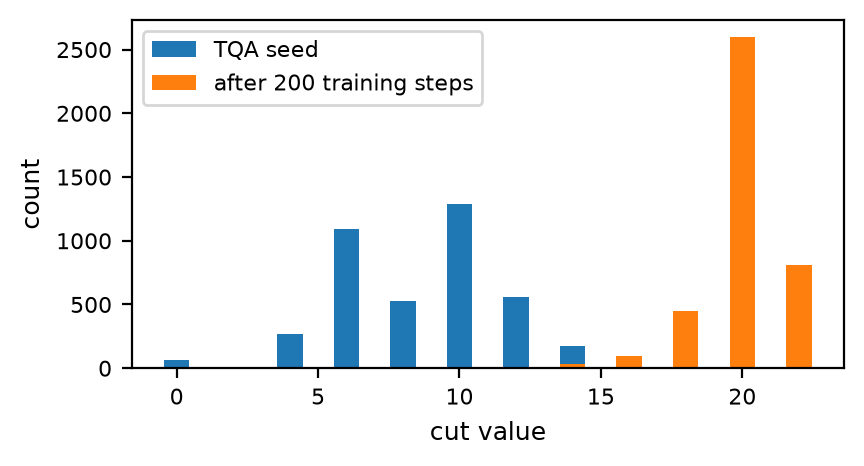

In [7]:
shots = 4000
initial_samples = pennylane_sample(
    circuit=qc.gates,
    thetas= torch.tensor(init_theta_np, dtype=torch.float64, device=device),
    n_qubits=n_qubits,
    shots=shots,
    max_qubits=20,
    seed=0,
)
final_samples = pennylane_sample(
    circuit=qc.gates,
    thetas=best_thetas.detach().cpu(),
    n_qubits=n_qubits,
    shots=shots,
    max_qubits=20,
    seed=0,
)
initial_samples_np = initial_samples.detach().cpu().numpy().astype(np.uint8)
final_samples_np = final_samples.detach().cpu().numpy().astype(np.uint8)


initial_cuts = np.array([cut_value_from_bits(row.tolist(), edges) for row in initial_samples_np], dtype=np.float64)
print('sampled mean cut (initial):', float(np.mean(initial_cuts)))
print('sampled best cut (initial):', int(np.max(initial_cuts)))

cuts = np.array([cut_value_from_bits(row.tolist(), edges) for row in final_samples_np], dtype=np.float64)
print('sampled mean cut:', float(np.mean(cuts)))
print('sampled best cut:', int(np.max(cuts)))
print('fraction optimal:', float(np.mean(cuts == best_cut)))

plt.figure(figsize=(4.39, 2.4))
plt.hist(initial_cuts, bins=np.arange(initial_cuts.min(), initial_cuts.max() + 2) - 0.5, rwidth=0.9, label = "TQA seed")
plt.hist(cuts, bins=np.arange(cuts.min(), cuts.max() + 2) - 0.5, rwidth=0.9, label = "after 200 training steps")
plt.xlabel('cut value')
plt.ylabel('count')
plt.tight_layout()
plt.legend()
import os as _os; _os.makedirs("figures", exist_ok=True); plt.savefig("figures/fig_qaoa_cut_hist.png", dpi=150, bbox_inches="tight")
plt.show()

## Reading results

- `sum<ZZ>` down -> expected cut up
- `qaoa best expected cut` close to classical max cut means good optimization
- sample histogram shows how concentrated trained circuit is on good cuts